<a href="https://colab.research.google.com/github/NikolaiMiranda/customer-segmentation-retail/blob/main/customer_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install ucimlrepo

In [130]:
import pandas as pd
from datetime import timedelta
from ucimlrepo import fetch_ucirepo
from sklearn.metrics import davies_bouldin_score
import numpy as np

Gather and clean the data:

In [131]:
# fetch dataset
online_retail = fetch_ucirepo(id=352)

# create a dataframe to hold the data
# reading through the documentation for ucimlrepo we find that our data is split into dataframe labeled "ids" and "features"
# we will joing those together to form one dataframe
# Check that both dataframes are the same length and then join them
print(len(online_retail.data.ids) == len(online_retail.data.features))
df = online_retail.data.ids.join(online_retail.data.features)

True


In [132]:
# View the data
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [133]:
# Check if we have null values
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [134]:
# We have missing cutomer IDs
# We remove these since we need the IDs to match customers to their purchases and segment them
df = df.dropna(subset=['CustomerID'])

# Check to make sure null values have been discarded
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


In [89]:
df[df['CustomerID'] == 12346]
# How do I get these to match up
# StockCode is same, Description is Same, Quantity could be same negtive or could be different, UnitPrice is Same, CustomerId is Same, Country is Same

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1/18/2011 10:01,1.04,12346.0,United Kingdom
61624,C541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,-74215,1/18/2011 10:17,1.04,12346.0,United Kingdom


In [136]:
import pandas as pd

# Step 1: Separate cancellations and originals
df_cancel = df[df['InvoiceNo'].str.startswith('C')].copy()
df_cancel['Quantity'] = df_cancel['Quantity'].abs()  # Make cancellation qty positive

df_original = df[~df['InvoiceNo'].str.startswith('C')].copy()

# Step 2: Group cancellations so multiple cancels get summed together
matching_cols = ['StockCode', 'Description', 'UnitPrice', 'CustomerID', 'Country']
df_cancel_grouped = df_cancel.groupby(matching_cols, as_index=False)['Quantity'].sum()
df_cancel_grouped.rename(columns={'Quantity': 'Quantity_cancel'}, inplace=True)

# Step 3: Merge grouped cancellations into originals
df_adjusted = pd.merge(
    df_original,
    df_cancel_grouped,
    on=matching_cols,
    how='left'
)

# Step 4: Adjust quantities (fill NaN cancellations with 0)
df_adjusted['Quantity_cancel'] = df_adjusted['Quantity_cancel'].fillna(0)
df_adjusted['Quantity'] = df_adjusted['Quantity'] - df_adjusted['Quantity_cancel']

# Step 5: Remove rows where adjusted quantity is zero or negative
df_adjusted = df_adjusted[df_adjusted['Quantity'] > 0].copy()

# Step 6: Drop the temporary 'Quantity_cancel' column
df_adjusted.drop(columns=['Quantity_cancel'], inplace=True)

# Step 7: Reset index
df_adjusted.reset_index(drop=True, inplace=True)

df = df_adjusted


In [137]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6.0,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6.0,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8.0,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6.0,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6.0,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
391308,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12.0,12/9/2011 12:50,0.85,12680.0,France
391309,581587,22899,CHILDREN'S APRON DOLLY GIRL,6.0,12/9/2011 12:50,2.10,12680.0,France
391310,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4.0,12/9/2011 12:50,4.15,12680.0,France
391311,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4.0,12/9/2011 12:50,4.15,12680.0,France


In [111]:
len(df)

391313

In [138]:
# The documentation states that if an order is cancelled the InvoiceNo will start with a 'c'
# We will remove all canceled orders from the data since we want to segment customers based on their purchases
df[df['InvoiceNo'].astype(str).str.startswith('C')]
# Note: ~ inverts the boolean

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country


In [139]:
# Look for likely outliers and remove them as well
# Discovered that some products has UnitPrice = 0
print(len(df[df['UnitPrice'] <= 0]))
# Remove products with UnitPrice = 0
df = df[df['UnitPrice'] > 0]
print(len(df[df['UnitPrice'] <= 0]))

40
0


Feature engineering:

In [144]:
# Create a total spend variable
df.loc[:, 'TotalSpend'] = df['Quantity'] * df['UnitPrice']

In [146]:
# Compute a reference date to use to create a recency variable
# We will calculate recency in terms of number of days from the "current date"
# We willuse the last day in the data set as the "current date"

# Make sure InvoiceDate is of type datetime
df.loc[:, 'InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
# Create a date to reference all other dates against
reference_date = df['InvoiceDate'].max()

In [147]:
# Create a summary dataframe using our additional features
customer_df = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (reference_date - x.max()).days), # Days since last purchase
    Frequency=('InvoiceNo', 'nunique'), # Number of unique invoices
    Monetary=('TotalSpend', 'sum'), # Total spend
    AvgQuantity = ('Quantity', 'mean'), # Average quantity per transaction
    ProductCount = ('StockCode', 'nunique'), # Number of unique products purchased
    Country = ('Country', lambda x: x.mode()[0]) # Most common country
)


customer_df.head()

,Recency,Frequency,Monetary,AvgQuantity,ProductCount,Country
CustomerID,,,,,,
12347.0,1,7,4310.00,13.505495,103,Iceland
12348.0,74,4,1797.24,75.516129,22,Finland
12349.0,18,1,1757.55,8.643836,73,Italy
12350.0,309,1,334.40,11.588235,17,Norway
12352.0,35,6,1405.28,5.895522,51,Norway


Segmentation using K-means:

In [148]:
# Feature Scaling for K-Means
from sklearn.preprocessing import StandardScaler

# Select the RFM features for clustering
features = customer_df[['Recency', 'Frequency', 'Monetary', 'AvgQuantity', 'ProductCount']]

# Initialize StandardScaler
scaler = StandardScaler()

# Fit and transform the features
customer_df_scaled = scaler.fit_transform(features)

# Convert the scaled array back to a DataFrame for easier handling
customer_df_scaled = pd.DataFrame(customer_df_scaled, columns=features.columns, index=customer_df.index)

customer_df_scaled.head() # Display the first few rows of the scaled data

,Recency,Frequency,Monetary,AvgQuantity,ProductCount
CustomerID,,,,,
12347.0,-0.906606,0.370453,0.297766,-0.074720,0.493992
12348.0,-0.179013,-0.028868,-0.011836,0.502970,-0.462630
12349.0,-0.737166,-0.428190,-0.016726,-0.120011,0.139687
12350.0,2.163240,-0.428190,-0.192075,-0.092581,-0.521681
12352.0,-0.567727,0.237346,-0.060130,-0.145614,-0.120136


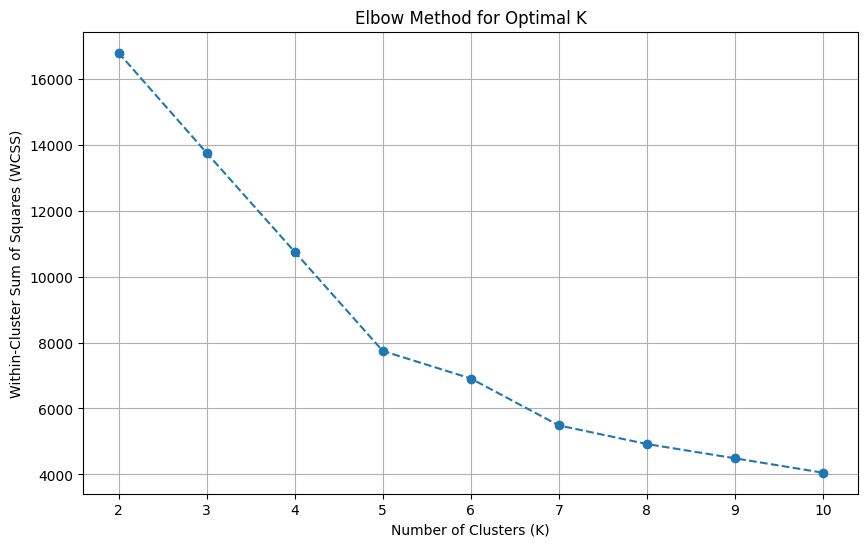

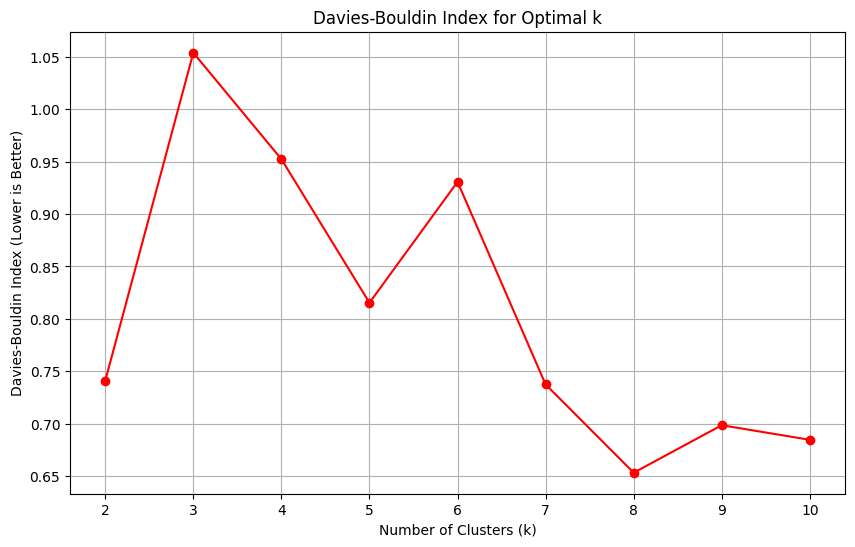

In [150]:
# Determine optimal number of clusters using the Elbow Method
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

wcss = []
dbi_scores = []
# Test different numbers of clusters from 2 to 10
for i in range(2, 11):
    # Elbow Method
    kmeans = KMeans(n_clusters=i, init='k-means++', n_init='auto', max_iter=3000, random_state=42)
    kmeans.fit(customer_df_scaled)
    wcss.append(kmeans.inertia_) # inertia_ is the WCSS

    # Davies-Bouldin Index
    dbi = davies_bouldin_score(customer_df_scaled, kmeans.labels_)
    dbi_scores.append(dbi)

# Plot the Elbow Method graph
plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.grid(True)
plt.show()

# Plot the Davies-Bouldin Index graph
plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), dbi_scores, marker='o', linestyle='-', color='r')
plt.title('Davies-Bouldin Index for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Davies-Bouldin Index (Lower is Better)')
plt.grid(True)
plt.show()

In [156]:
# Apply K-Means Clustering with K=4
from sklearn.cluster import KMeans

# Initialize KMeans with the chosen K (4)
# n_init='auto' is the modern default for n_init
kmeans = KMeans(n_clusters=5, init='k-means++', n_init='auto', max_iter=3000, random_state=3)

# Fit KMeans to the scaled RFM data and get cluster labels
customer_df['Cluster_KMeans'] = kmeans.fit_predict(customer_df_scaled)

customer_df.head() # Display rfm_df with the new Cluster_KMeans column

,Recency,Frequency,Monetary,AvgQuantity,ProductCount,Country,Cluster_KMeans
CustomerID,,,,,,,
12347.0,1,7,4310.00,13.505495,103,Iceland,1
12348.0,74,4,1797.24,75.516129,22,Finland,1
12349.0,18,1,1757.55,8.643836,73,Italy,1
12350.0,309,1,334.40,11.588235,17,Norway,4
12352.0,35,6,1405.28,5.895522,51,Norway,1


In [157]:
# Analyze K-Means Cluster Characteristics
# Use customer_df (original, unscaled values) for meaningful averages
customer_df2 = customer_df.reset_index()
kmeans_cluster_analysis = customer_df2.groupby('Cluster_KMeans').agg(
    AvgRecency=('Recency', 'mean'),
    AvgFrequency=('Frequency', 'mean'),
    AvgMonetary=('Monetary', 'mean'),
    CustomerCount=('CustomerID', 'count'), # Assuming CustomerID is now a regular column due to previous reset_index
    AvgQuantity=('AvgQuantity', 'mean'),
    AvgProductCount=('ProductCount', 'mean')
).sort_values(by='AvgMonetary', ascending=False) # Sort by Monetary for easier comparison

kmeans_cluster_analysis

,AvgRecency,AvgFrequency,AvgMonetary,CustomerCount,AvgQuantity,AvgProductCount
Cluster_KMeans,,,,,,
2,102.133333,15.866667,60901.606667,15,1338.372263,96.000000
3,0.333333,173.000000,59270.440000,3,7.217656,1592.333333
0,14.487864,15.393204,7987.357937,412,17.323404,218.390777
1,45.008445,3.340605,1158.235458,2842,17.261705,50.344476
4,249.110161,1.562203,488.788880,1053,15.962200,24.023742


/tmp/ipython-input-3069119480.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=customer_df2, x='Cluster_KMeans', palette='viridis')


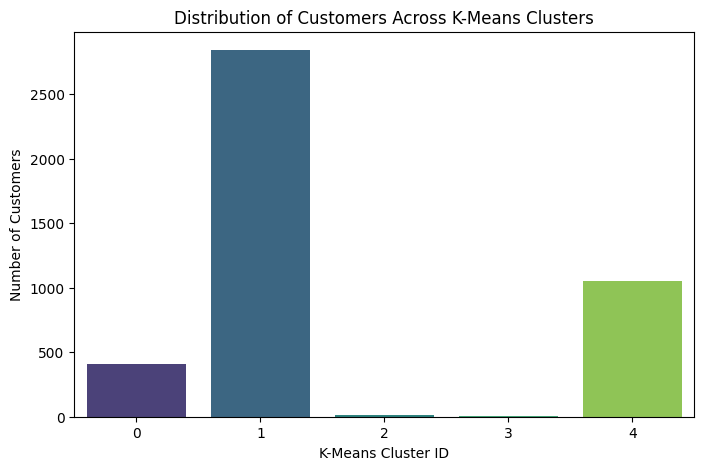

In [158]:
# Visualize K-Means Cluster Sizes
plt.figure(figsize=(8, 5))
sns.countplot(data=customer_df2, x='Cluster_KMeans', palette='viridis')
plt.title('Distribution of Customers Across K-Means Clusters')
plt.xlabel('K-Means Cluster ID')
plt.ylabel('Number of Customers')
plt.show()

In [159]:
# Map K-Means Cluster IDs to descriptive names

# IMPORTANT: VERIFY THESE MAPPINGS AGAINST YOUR ACTUAL kmeans_cluster_analysis OUTPUT
# The cluster IDs (0, 1, 2) are arbitrary and can change with each run.
# Adjust the dictionary below based on the AvgRecency, AvgFrequency, and AvgMonetary for YOUR Cluster 0, 1, and 2.

# Example mapping (adjust based on your actual output):
# Based on my interpretation in the text above:
# Assuming Cluster 0 is At-Risk/Lapsed
# Assuming Cluster 1 is Champions/Loyal
# Assuming Cluster 2 is Potential/Developing
cluster_name_mapping = {
    0: 'Avg',
    1: 'At-Risk',
    2: 'Loyalists',
    3: 'Elite Members'
}

customer_df2['KMeans_Cluster_Name'] = customer_df2['Cluster_KMeans'].map(cluster_name_mapping)

customer_df2.head() # Display rfm_df with the new KMeans_Cluster_Name column

,CustomerID,Recency,Frequency,Monetary,AvgQuantity,ProductCount,Country,Cluster_KMeans,KMeans_Cluster_Name
0,12347.0,1,7,4310.00,13.505495,103,Iceland,1,At-Risk
1,12348.0,74,4,1797.24,75.516129,22,Finland,1,At-Risk
2,12349.0,18,1,1757.55,8.643836,73,Italy,1,At-Risk
3,12350.0,309,1,334.40,11.588235,17,Norway,4,NaN
4,12352.0,35,6,1405.28,5.895522,51,Norway,1,At-Risk


In [155]:
# Count customers in each named K-Means cluster
customer_df2['KMeans_Cluster_Name'].value_counts()

,count
KMeans_Cluster_Name,
At-Risk,3328
Avg,970
Loyalists,24
Elite Members,3
